# Analiza językowa

In [1]:
import wordfreq as wq
from matplotlib import pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wiki_scraper import WikiScraper, Analyzer

Funkcja lang_confidence_score tworzy listy rankingowe słów z tekstu i języka (im częściej słowo się pojawia, tym wyższa pozycja w rankingu).

Stopień braku podobieństwa między listami definiujemy następująco: $D(T,L) = \sum_{w \in words(T)} \bigl| r_T(w) - r_L(w) \bigr|$ gdzie $r_T(w)$ to pozycja słowa $w$ w rankingu tekstu, a $r_L(w)$ to pozycja w rankingu języka.

Za słowa, których nie ma w liście języka jest naliczana kara równa długości listy rankingowej języka.
Na pierwszych pozycjach rankingu będą słowa funkcyjne (np. the).
Jeśli ranking tekstu jest zbliżony do rankingu języka, to prawdopodobnie tekst został napisany w tym samym języku.

In [2]:
def lang_confidence_score(word_counts, language_words_with_frequency):
    """
    word_counts: dictionary {word: number of occurrences}
    language_words_with_frequency: list of tuples [(word, frequency)]
    """
    if not word_counts:
        return 0.0

    # Lista rankingowa słów z tekstu. Ograniczona do długości listy słów z języka (gdy tekst ma dluzszy ranking, to bardzo często będzie pojawiać się kara)
    sorted_text_words = sorted(word_counts.keys(), key=lambda x: word_counts[x], reverse=True)[:int(len(language_words_with_frequency)/2)]
    # Dla duzych zbiorów słów warto ograniczyć się do górnej połowy rankingu, żeby zwiększyć pewność (i zmniejszyc wplyw tematyki tekstu)
    #sorted_text_words = sorted(word_counts.keys(), key=lambda x: word_counts[x], reverse=True)[:int(len(language_words_with_frequency))]
    text_profile = {word: rank for rank, word in enumerate(sorted_text_words, 1)}

    # Lista rankigowa słów z języka
    lang_profile = {word: rank for rank, (word, freq) in enumerate(language_words_with_frequency, 1)}
    # Kara za słowa spoza języka - długość listy słów z języka
    max_penalty = len(language_words_with_frequency)

    total_distance = 0

    # Obliczanie odległości między tekstami
    for word, text_rank in text_profile.items():
        if word in lang_profile:
            lang_rank = lang_profile[word]
            # Odległość to różnica w pozycjach rankogowych każdego słowa
            total_distance += abs(text_rank - lang_rank)
        else:
            # Nieznane słowo -> kara
            total_distance += max_penalty

    # Najdalsza mozliwa odleglosc jest gdy wszystkie slowa sa spoza jezyka
    max_possible_distance = len(text_profile) * max_penalty

    if max_possible_distance == 0:
        return 0.0
    # Normalizacja do [0, 1] gdzie 1 to idealne dopasowanie
    confidence = 1 - (total_distance / max_possible_distance)
    return confidence

# Dane
* Wybrane języki to angielski, polski i niemiecki
* lista co najmniej 100 najczęściej używanych słów w językach z paczki wordfreq
* dłuższy artykuł z wiki - artykuł dostępny pod frazą "Ash Ketchum" - dobry do analizy, ponieważ jest długi (około 20 000 słów w tym 3500 unikalnych)
* krótki artykuł z wiki  - artykuł dostępny pod frazą "CPD02" - dobrany tak, żeby wynik był jak najniższy (około 200 słów w tym większość to nazwy własne)
* tekst spoza wiki po angielsku - "Alice's Adventures in Wonderland" Lewisa Carrola (dostępne pod adresem https://www.gutenberg.org/cache/epub/11/pg11.txt w domenie publicznej)
* tekst spoza wiki po polsku - "Lalka (Tom pierwszy)" Bolesława Prusa (dostępne pod adresem https://wolnelektury.pl/media/book/txt/lalka-tom-pierwszy.txt w domenie publicznej)
* tekst spoza wiki po niemiecku - "Die Leiden des jungen Werther" ("Cierpienia młodego Wertera") Johanna Wolfganga von Goethego (dostępne pod adresem https://www.gutenberg.org/cache/epub/2407/pg2407.txt w domenie publicznej)

In [ ]:
# Skrypt pobierający analizowane długie teksty
# import requests
# response = requests.get("https://wolnelektury.pl/media/book/txt/lalka-tom-pierwszy.txt")
# with open("lalka-tom-pierwszy.txt", 'w') as f:
#     f.write(response.text)
#
# response = requests.get("https://www.gutenberg.org/cache/epub/11/pg11.txt")
# with open("alice-adventures-in-wonderland.txt", 'w') as f:
#     f.write(response.text)
#
# response = requests.get("https://www.gutenberg.org/cache/epub/2407/pg2407.txt")
# with open("die-leiden-des-jungen-werther.txt", 'w') as f:
#     f.write(response.text)

In [3]:
# Dluzszy artykuł z wiki - zamiast pliku JSON korzystam z biblioteki wikiscraper, żeby uzyskać słownik bezpośrednio
w_scraper = WikiScraper("Ash Ketchum")
wiki_counts = w_scraper.count_words()
# Krótszy artykuł z wiki
bad_scraper = WikiScraper("CPD02")
bad_counts = bad_scraper.count_words()

# Listy najczęściej używanych słów z paczki wordfreq
en_language_words = wq.top_n_list('en', 5000)
en_language_words_with_freq = [(w, wq.word_frequency(w, 'en')) for w in en_language_words]

pl_language_words = wq.top_n_list('pl', 5000)
pl_language_words_with_freq = [(w, wq.word_frequency(w, 'pl')) for w in pl_language_words]

de_language_words = wq.top_n_list('de', 5000)
de_language_words_with_freq = [(w, wq.word_frequency(w, 'de')) for w in de_language_words]

analyzer = Analyzer()
# Polski tekst - "Lalka" Bolesława Prusa (źródło: https://wolnelektury.pl/media/book/txt/lalka-tom-pierwszy.txt )
with open("lalka-tom-pierwszy.txt") as f:
    polish_raw_text = f.read()
polish_book_count = analyzer.count_words(polish_raw_text)

with open("alice-adventures-in-wonderland.txt") as f:
    english_book_text = f.read()
english_book_count = analyzer.count_words(english_book_text)

with open("die-leiden-des-jungen-werther.txt") as f:
    german_book_text = f.read()
german_book_count = analyzer.count_words(german_book_text)

Updated word counts in word-counts.json
Updated word counts in word-counts.json


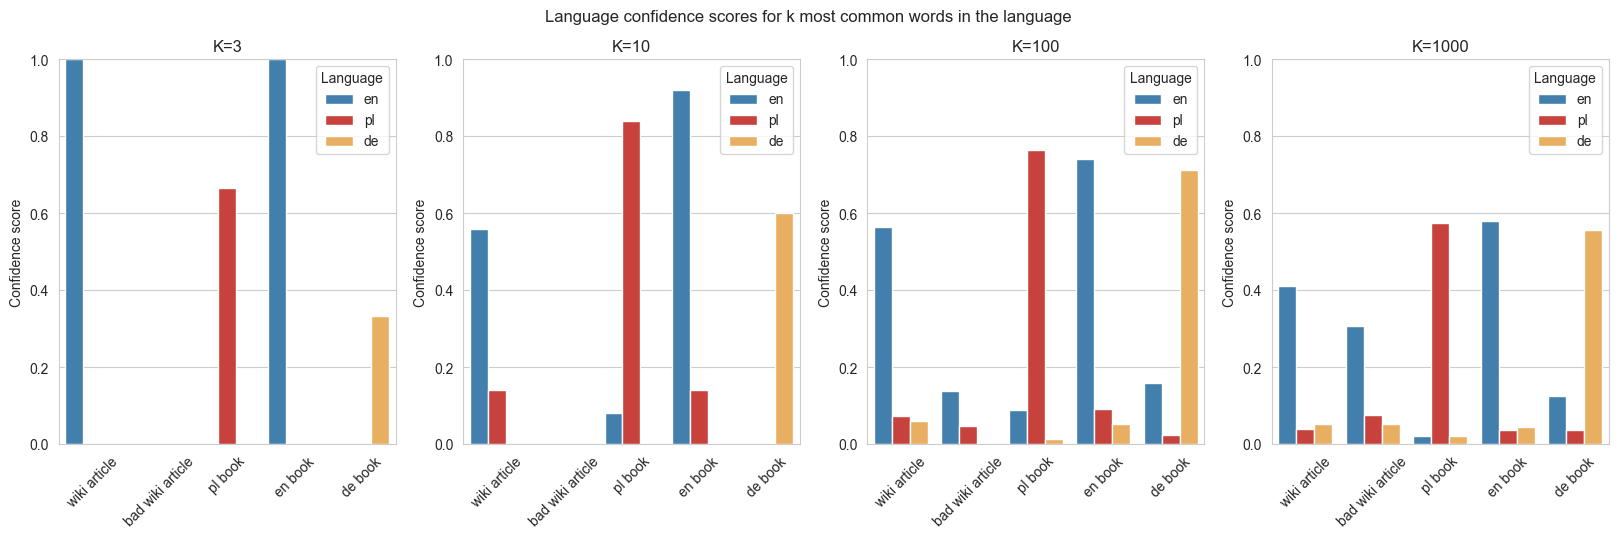

In [4]:
# Dane w postaci przygotowanej do wizualizacji
long_texts = [(wiki_counts, 'wiki article'), (bad_counts, 'bad wiki article'), (polish_book_count, 'pl book'), (english_book_count, 'en book'), (german_book_count, 'de book')] # lista krotek (tekst, opis tekstu)
lang_dicts = [(en_language_words_with_freq, 'en'), (pl_language_words_with_freq, 'pl'), (de_language_words_with_freq, 'de')] # lista krotek (slownik jezyka, nazwa jezyka)
k_values = [3, 10, 100, 1000]

def prepare_dataframe(k):
    rows = []
    for l_text in long_texts:
        for l_dict in lang_dicts:
            text, t_label = l_text
            lang, l_label = l_dict
            result = lang_confidence_score(text, lang[:k])
            rows.append([t_label, l_label, result])
    df = pd.DataFrame(rows)
    df.columns = ['Text', 'Language', 'Score']
    return df

sns.set_style("whitegrid")
fig, axs = plt.subplots(1, len(k_values), figsize=(20, 5))

custom_palette = {
    'pl': '#de2d26',    # Czerwony
    'en': '#3182bd', # Niebieski
    'de': '#feb24c',  # Żółty/Pomarańczowy
}

fig.suptitle('Language confidence scores for k most common words in the language')

for i, K in enumerate(k_values):
    df = prepare_dataframe(K)
    sns.barplot(data=df, x='Text', y='Score', hue='Language', ax=axs[i], legend=True, palette=custom_palette, errorbar=None)
    axs[i].set_title(f'K={K}')
    axs[i].set_ylim(0, 1)
    axs[i].set_xlabel(' ')
    axs[i].set_ylabel('Confidence score')
    axs[i].tick_params(axis='x', rotation=45)

plt.show()

# Obserwacje:
* Metoda z rangami jest skuteczna - niezależnie od liczby słów potrafi poprawnie zidentyfikować język danego tekstu z wyraźną dominacją poprawnego języka
* Duży wpływ na wynik funkcji mają wyrazy funkcyjne (przyimki, spójniki np. the, die, w), które zajmują najwyższe pozycje w rankingach języków - dlatego wyniki dla angielskiego dla k=3 są tak wysokie
* Kiedy tekst nie posiada wielu wyrazów funkcyjnych, to funkcja może nie dawać żadnego miarodajnego wyniku - słaby tekst z wiki dostaje wyniki = 0 dla każdego języka, ponieważ dominują w nim nazwy własne
* Wraz z rosnącym k, wyniki maleją - w tekście jest branych coraz więcej słów, które nie występują w słowniku (co powoduje naliczanie kar) lub występują 1-2 razy
* Funkcja nie uwzględnia dokładnej częstotliwości, ale tylko pozycje na liście rankingowej popularności w tekście i języku - krótkie teksty o konkretnej tematyce mogą mieć dużo słów, które są wysoko w liście rankingowej tekstu, ale nisko w rankingu języka

# Odpowiedzi na pytania:

1. Czy dobór języków miał duże znaczenie?

Wybrane języki dosyć mocno różnią się w pisowni, przez co rankingi mocno się różnią.
Języki były dobierane w taki sposób, żeby się różniły cechami charakterystycznymi (w angielskim słowa prawie się nie odmieniają, a w polskim bardzo często), ale te cechy znacząco nie psują wyników.

2. Czy po wartościach language_words_with_frequency dla danych i najczęstszych słowach z języka danych widać, że w wybranym języku słowa często są odmieniane?

Dla małych k (w szczególnosci k = 3 i k = 10) widać różnice w wartościach language_words_with_frequency dla angielskiego i polskiego. Ponieważ w początkowych pozycjach rankingów dominują słowa funkcyjne, ktore nie są odmieniane.
W języku polskim częste odmienianie słów może powodować zaniżanie pozycji słów w rankingu, ale psuje to znacząco wyników funkcji.

3. Czy trudne było znalezienie takiego artykułu, dla którego wynik language_words_with_frequency jest jak najmniejszy w języku wiki? Czy to specyfika tego wiki?

Znalezienie artykułu, dla którego wynik funkcji jest niski nie było bardzo trudne - wystarczyło znaleźć krótki artykuł, w którym jest mało pełnych zdań i dużo nazw własnych, które często pojawiają się w wiki.